In [80]:
import os
from pathlib import Path
from typing import Sequence, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from collections import Counter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

mpl.rcParams.update({
    "lines.linewidth": 2,
    "lines.markersize": 4.5,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "legend.frameon": False,
    "axes.grid": False,
})

simplicity bias function

In [96]:
# Simulation helpers (eq_to_paper_params, rhs_paper, run_simulation)
def eq_to_paper_params(p_eq: Sequence[float]) -> np.ndarray:
    p_eq = np.asarray(p_eq, dtype=float)
    if p_eq.size != 15:
        raise ValueError("Expected 15 parameters in equation order")
    (thetaA, thetaR, gammaA, gammaR, gammaC,
     alphaA, alphaAp, alphaR, alphaRp,
     deltaMA, deltaMR, deltaA, deltaR,
     betaA, betaR) = p_eq

    return np.array([
        gammaC, deltaA, deltaR, gammaA, thetaA,
        alphaA, alphaAp, deltaMA, betaA, gammaR,
        thetaR, alphaR, alphaRp, deltaMR, betaR
    ], dtype=float)

def rhs_paper(t: float, y: np.ndarray, p: Sequence[float]) -> np.ndarray:
    u = np.asarray(y, dtype=float)
    p = np.asarray(p, dtype=float)
    u0,u1,u2,u3,u4,u5,u6,u7,u8 = u
    gammaC, deltaA, deltaR, gammaA, thetaA, alphaA, alphaAp, deltaMA, betaA, gammaR, thetaR, alphaR, alphaRp, deltaMR, betaR = p
    p0, p1, p2, p3, p4 = thetaA, thetaR, gammaA, gammaR, gammaC
    p5, p6, p7, p8, p9 = alphaA, alphaAp, alphaR, alphaRp, deltaMA
    p10, p11, p12, p13, p14 = deltaMR, deltaA, deltaR, betaA, betaR
    f0 = p0*u2 - p2*u0*u5
    f1 = p1*u3 - p3*u1*u5
    f2 = p2*u0*u5 - p0*u2
    f3 = p3*u1*u5 - p1*u3
    f4 = p6*u2 + p5*u0 - p9*u4
    f5 = p13*u4 + p0*u2 + p1*u3 - u5*(p2*u0 + p3*u1 + p4*u7 + p11)
    f6 = p8*u3 + p7*u1 - p10*u6
    f7 = p14*u6 - p4*u5*u7 + p11*u8 - p12*u7
    f8 = p4*u5*u7 - p11*u8
    return np.array([f0,f1,f2,f3,f4,f5,f6,f7,f8], dtype=float)

def run_simulation(p_paper: Sequence[float], u0: Sequence[float], t0: float=0.0, tf: float=10.0, t_eval: Optional[np.ndarray]=None, method: str="BDF") -> Tuple[np.ndarray, np.ndarray]:
    p_paper = np.asarray(p_paper, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    if t_eval is None:
        t_eval = np.linspace(t0, tf, 1000)
    def fun(t, y):
        return rhs_paper(t, y, p_paper)
    sol = solve_ivp(fun, (t0, tf), u0, method=method, t_eval=t_eval, atol=1e-9, rtol=1e-9, max_step=0.5)
    if not sol.success:
        raise RuntimeError("Solver failed: " + sol.message)
    return sol.t, sol.y.T

# Small plot helpers (axis-aware)
def plot_state_ax(ax, t: np.ndarray, y: np.ndarray, idx: int, ic_names=None, sigma=None, color="green", title=None):
    label = (ic_names[idx] if ic_names is not None else f"state_{idx}")
    ax.plot(t, y[:, idx], label=label, linewidth=1.5, color=color)
    if sigma is not None:
        sarr = np.asarray(sigma)
        if sarr.ndim == 0:
            s = float(sarr)
        elif sarr.shape[0] == y.shape[1]:
            s = float(sarr[idx])
        else:
            raise ValueError("sigma must be scalar or length n_states")
        ax.fill_between(t, y[:, idx]-s, y[:, idx]+s, color=color, alpha=0.15, linewidth=0)
    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("Concentration (M)")
    if title:
        ax.set_title(title)
    ax.grid(False)

# Frequency polygon loader + plot (rand & 0_mut only)
def load_complexities_for_length(path: Path, phenotype_length: int):
    if not Path(path).exists():
        raise FileNotFoundError(f"{path} not found")
    try:
        df = pd.read_csv(path, sep="\t")
    except Exception:
        df = pd.read_csv(path, sep="\t", engine="python")
    if df.columns.size and isinstance(df.columns[0], str) and df.columns[0].startswith("#"):
        df = pd.read_csv(path, sep="\t", skiprows=1, names=["file_number","genotype_raw","phenotype_binary","complexity_entropy"], engine="python")
    if "phenotype_binary" not in df.columns and "phenotype" in df.columns:
        df = df.rename(columns={"phenotype":"phenotype_binary"})
    if "phenotype_binary" not in df.columns:
        raise ValueError(f"No phenotype column in {path}")
    df["phenotype_binary"] = df["phenotype_binary"].astype(str)
    df["phenotype_length"] = df["phenotype_binary"].str.len()
    df_f = df[df["phenotype_length"] == phenotype_length]
    if "complexity_entropy" not in df_f.columns:
        possible = [c for c in df_f.columns if "complex" in c.lower()]
        if possible:
            df_f = df_f.rename(columns={possible[0]:"complexity_entropy"})
        else:
            raise ValueError(f"No complexity column found in {path}")
    comps = pd.to_numeric(df_f["complexity_entropy"], errors="coerce").dropna().to_numpy()
    comps = comps[comps > 0]
    return comps

def plot_frequency_polygon_ax(ax, rand_path, zero_path, phenotype_length=50, bin_width=3.0, label_rand="G-dist", label_zero="P-dist"):
    rand_raw = load_complexities_for_length(rand_path, phenotype_length)
    zero_raw = load_complexities_for_length(zero_path, phenotype_length)
    g_mean = np.mean(rand_raw) if rand_raw.size else np.nan
    p_mean = np.mean(zero_raw) if zero_raw.size else np.nan
    print(f"G mean={g_mean:.6f}, n={len(rand_raw)}; P mean={p_mean:.6f}, n={len(zero_raw)}")
    all_data = np.concatenate([rand_raw, zero_raw])
    min_val, max_val = float(np.min(all_data)), float(np.max(all_data))
    bins = np.arange(min_val, max_val + bin_width, bin_width)
    rand_counts, edges = np.histogram(rand_raw, bins=bins, density=False)
    zero_counts, _ = np.histogram(zero_raw, bins=bins, density=False)
    if rand_counts.sum() > 0:
        rand_counts = rand_counts / rand_counts.sum()
    if zero_counts.sum() > 0:
        zero_counts = zero_counts / zero_counts.sum()
    centers = 0.5 * (edges[:-1] + edges[1:])
    nonzeros = np.concatenate([rand_counts[rand_counts>0], zero_counts[zero_counts>0]])
    eps = float(nonzeros.min() * 0.1) if nonzeros.size else 1e-12
    rand_safe = np.clip(rand_counts, eps, None)
    zero_safe = np.clip(zero_counts, eps, None)
    ax.plot(centers, rand_counts, marker="o", color="orange", label=label_rand, linewidth=2)
    ax.fill_between(centers, rand_counts, 0, color="orange", alpha=0.18)
    ax.plot(centers, zero_counts, marker="o", color="blue", label=label_zero, linewidth=2)
    ax.fill_between(centers, zero_counts, 0, color="blue", alpha=0.15)
    ax.set_xlabel("Complexity (Lempel-Ziv)")
    ax.set_ylabel("Relative Frequency")
    ax.legend(frameon=False, loc="upper left")
    ax.grid(False)
    ax.set_axisbelow(True)

# simplicity bias panel (axis-aware)
def plot_simplicity_bias_ax(ax, input_file, length_filter=50):
    p = Path(input_file)
    if not p.exists():
        ax.text(0.5,0.5,f"Missing file:\n{input_file}", ha='center', va='center')
        return
    df = pd.read_csv(p, sep='\t')
    if 'phenotype_binary' not in df.columns or 'complexity_entropy' not in df.columns:
        ax.text(0.5,0.5,"Required cols missing", ha='center', va='center')
        return
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df['phenotype_length'] = df['phenotype_binary'].str.len()
    df = df[df['phenotype_length'] == length_filter]
    binaries = df['phenotype_binary'].tolist()
    total = len(binaries)
    if total == 0:
        ax.text(0.5,0.5,"No data (length filter)", ha='center', va='center')
        return
    counts = Counter(binaries)
    lz_map = dict(zip(df['phenotype_binary'], df['complexity_entropy']))
    lz_vals = []
    logps = []
    for b, c in counts.items():
        prob = c/total
        lz_vals.append(lz_map[b])
        logps.append(np.log10(prob))
    ax.scatter(np.array(lz_vals), np.array(logps), alpha=0.7, s=30,color='darkorange')
    ax.set_xlabel("Complexity $\widetilde{K}(x)$")
    ax.set_ylabel("log$_{10}$(Probability)")
    ax.grid(False)

<>:151: SyntaxWarning: invalid escape sequence '\w'
<>:151: SyntaxWarning: invalid escape sequence '\w'
/var/folders/yr/bzwkxpcj34x73kc2trlk0h2m0000gn/T/ipykernel_72891/2730193380.py:151: SyntaxWarning: invalid escape sequence '\w'
  ax.set_xlabel("Complexity $\widetilde{K}(x)$")


G mean=12.843835, n=9998; P mean=21.806167, n=420
G mean=24.898531, n=10000; P mean=29.876560, n=5369
G mean=30.439773, n=10000; P mean=33.364258, n=7501
G mean=31.636736, n=10000; P mean=34.071498, n=7225
Saved stacked figure to /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/appendix/three_panel_stack_Ts_10_50_100_500.png


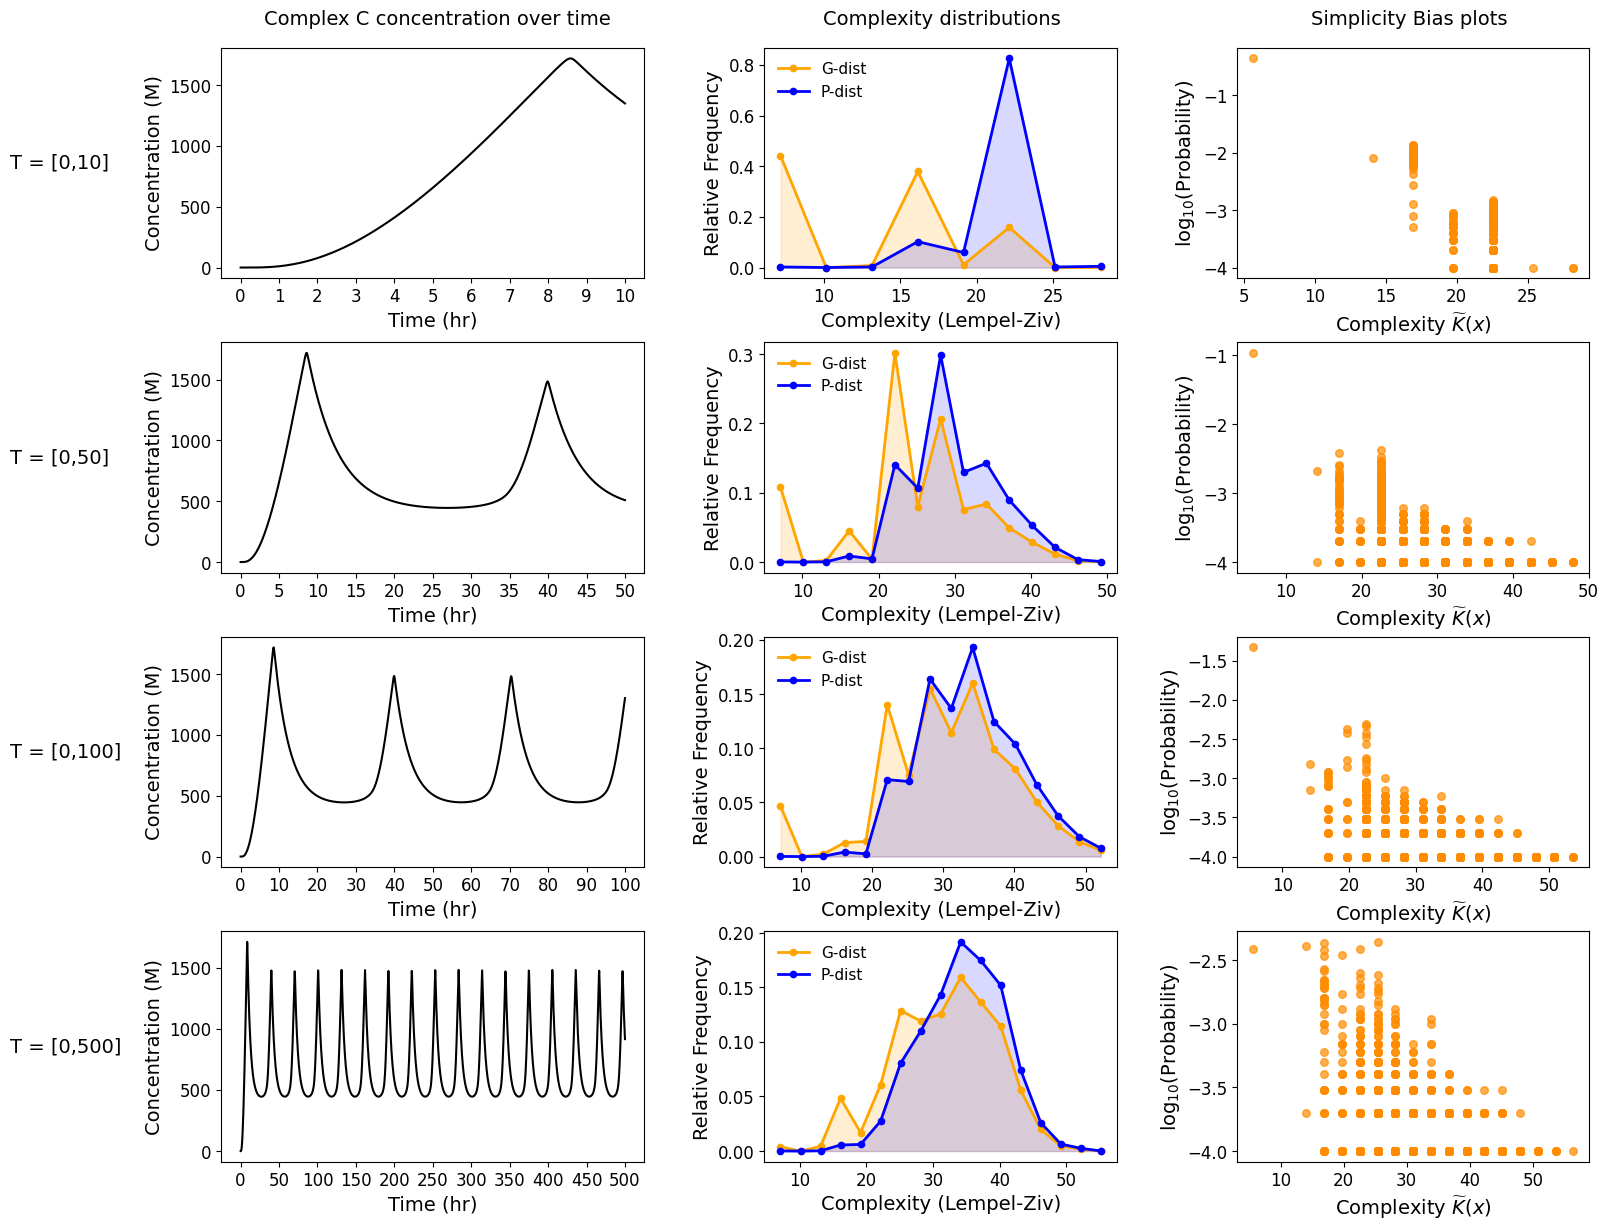

In [133]:
# ============================================================
# Final stacked figure with all time windows fully active
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Explicit full file paths
# ------------------------------------------------------------

# ---- T = 10 ----
SB_FILE_T10 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
                    "mut_project_updates/figures/circ_model/appendix/0to10/data_table_10.txt")

FREQ_RAND_T10 = SB_FILE_T10
FREQ_ZERO_T10 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
                     "mut_project_updates/figures/circ_model/appendix/0to10/mut0_table.txt")
# ---- T = 50 ----
FREQ_RAND_T50 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/appendix/0to50/t0to50_table.txt")

FREQ_ZERO_T50 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_a/plot_a_files/compiled_0mut.txt")

SB_FILE_T50 = FREQ_RAND_T50

# ---- T = 100 ----
FREQ_RAND_T100 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
                      "mut_project_updates/figures/circ_model/appendix/0to100/data_table_100.txt")

FREQ_ZERO_T100 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
                      "mut_project_updates/figures/circ_model/appendix/0to100/mut0_table.txt")

SB_FILE_T100 = FREQ_RAND_T100

# ---- T = 500 ----
FREQ_RAND_T500 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
                      "mut_project_updates/figures/circ_model/appendix/0to500/data_table_500.txt")
FREQ_ZERO_T500 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
                      "mut_project_updates/figures/circ_model/appendix/0to500/mut0_table.txt")

SB_FILE_T500 = FREQ_RAND_T500

# ------------------------------------------------------------
# Map TF → files cleanly
# ------------------------------------------------------------

FILES = {
    10.0: dict(freq_rand=FREQ_RAND_T10,
               freq_zero=FREQ_ZERO_T10,
               sb=SB_FILE_T10),

    50.0: dict(freq_rand=FREQ_RAND_T50,
               freq_zero=FREQ_ZERO_T50,
               sb=SB_FILE_T50),

    100.0: dict(freq_rand=FREQ_RAND_T100,
                freq_zero=FREQ_ZERO_T100,
                sb=SB_FILE_T100),

    500.0: dict(freq_rand=FREQ_RAND_T500,
                freq_zero=FREQ_ZERO_T500,
                sb=SB_FILE_T500),
}

# ------------------------------------------------------------
# Model parameters
# ------------------------------------------------------------

p_eq = np.array([
    6.25e+01,   # thetaA = 62.5
    2.00e+02,   # thetaR = 200
    5.00e-01,   # gammaA = 0.5
    1.25e+00,   # gammaR = 1.25
    1.00e+00,   # gammaC = 1.0
    6.25e+01,   # alphaA = 62.5
    3.75e+02,   # alphaAp = 375
    5.00e-03,   # alphaR = 0.005
    5.00e+01,   # alphaRp = 50
    1.50e+01,   # deltaMA = 15
    2.50e-01,   # deltaMR = 0.25
    2.50e-01,   # deltaA = 0.25
    3.50e-01,   # deltaR = 0.35
    2.50e+01,   # betaA = 25
    2.50e+00    # betaR = 2.5
])

p_true = eq_to_paper_params(p_eq)
u_true = np.array([1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0])
ic_names = ['D_A','D_R',"D'_A","D'_R",'M_A','A','M_R','R','C']

# ------------------------------------------------------------
# Time windows
# ------------------------------------------------------------

TF_list = [10.0, 50.0, 100.0, 500.0]
nrows = len(TF_list)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=3,
    figsize=(18, 3.2*nrows),
    gridspec_kw={'width_ratios':[1.2,1.0,1.0]}
)

fig.subplots_adjust(
    left=0.22,
    right=0.98,
    top=0.94,
    bottom=0.07,
    hspace=0.28,
    wspace=0.32
)

# Column headers
fig.text(0.34, 0.97, "Complex C concentration over time",
         ha='center', va='top',
         fontsize=plt.rcParams["axes.titlesize"])

fig.text(0.62, 0.97, "Complexity distributions",
         ha='center', va='top',
         fontsize=plt.rcParams["axes.titlesize"])

fig.text(0.88, 0.97, "Simplicity Bias plots",
         ha='center', va='top',
         fontsize=plt.rcParams["axes.titlesize"])

# ------------------------------------------------------------
# Loop over time windows
# ------------------------------------------------------------

for r, TF in enumerate(TF_list):

    ax_left, ax_mid, ax_right = axes[r]

    ax_left.cla(); ax_mid.cla(); ax_right.cla()

    # Row label
    ax_left.annotate(
        f"T = [0,{int(TF)}]",
        xy=(-0.5, 0.5),
        xycoords='axes fraction',
        fontsize=plt.rcParams["axes.labelsize"],
        ha='left',
        va='center'
    )

    # ----- LEFT: C(t) -----
    t_eval = np.linspace(0, TF, 1000 if TF <= 100 else 2000)
    t, y_true = run_simulation(p_true, u_true, t0=0.0, tf=TF, t_eval=t_eval)

    plot_state_ax(ax_left, t, y_true, idx=8,
                  ic_names=ic_names,
                  color='black')

    ax_left.set_xticks(np.linspace(0, TF, min(11, int(TF)+1)))

    # ----- MIDDLE: Frequency polygon -----
    freq_rand = FILES[TF]["freq_rand"]
    freq_zero = FILES[TF]["freq_zero"]

    plot_frequency_polygon_ax(
        ax_mid,
        freq_rand,
        freq_zero,
        phenotype_length=50,
        bin_width=3.0
    )

    # ----- RIGHT: Simplicity bias -----
    sb_file = FILES[TF]["sb"]

    plot_simplicity_bias_ax(
        ax_right,
        input_file=str(sb_file),
        length_filter=50
    )

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

out = Path(f"three_panel_stack_Ts_{'_'.join(str(int(x)) for x in TF_list)}.png")
plt.savefig(out, dpi=300, bbox_inches='tight')
print("Saved stacked figure to", out.resolve())
plt.show()

In [112]:
import pandas as pd
from collections import Counter

df = pd.read_csv("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_a/plot_a_files/t0to50_table.txt", sep="\t")

counts = Counter(df["phenotype_binary"])
print("Total rows:", len(df))
print("Unique phenotypes:", len(counts))
print("Max count of a phenotype:", max(counts.values()))

Total rows: 10000
Unique phenotypes: 5369
Max count of a phenotype: 1084
